In [1]:
pip install shap


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap 
from xgboost import XGBClassifier

all_matches_features = pd.read_csv("/Users/mariusschonberg/Desktop/Speciale/outputs/outputs/all_matches_features_final.csv")
all_matches_features.head()

,game_id,event_pk,event_id,type_id,period_id,min,sec,timestamp_utc,team_id,player_id,...,obstruction_count,defender_dist_2,free_angle,defender_dist_mean3,ball_speed_mps,shooter_speed_mps,def_speed_mean_r5m,closing_speed_mean_r5m,possession_length,fast_break
0,2442545,2701835291,51,13,1,6,55,2024-07-19T16:09:57.893,1000,186734,...,1.0,5.322875,0.211143,4.378393,NaN,0.353553,0.8000,NaN,NaN,NaN
1,2442545,2701835473,63,15,1,7,36,2024-07-19T16:10:39.243,420,223813,...,2.0,3.717109,0.275043,3.345797,NaN,1.250000,0.4200,NaN,41.0,0.0
2,2442545,2701835395,62,16,1,7,37,2024-07-19T16:10:40.394,420,485358,...,1.0,2.073933,1.087887,2.121542,NaN,3.132491,0.5075,NaN,1.0,1.0
3,2442545,2701835777,74,15,1,9,38,2024-07-19T16:12:40.766,420,422348,...,0.0,11.125331,0.077660,10.262173,NaN,3.354102,1.3000,NaN,121.0,0.0
4,2442545,2701836305,112,15,1,12,45,2024-07-19T16:15:48.148,420,223813,...,1.0,10.688919,0.132392,11.001894,18.374575,0.750000,3.0600,2.061376,187.0,0.0


In [3]:


sys.path.insert(0, "/Users/mariusschonberg/Desktop/Speciale/code/models")
from Utils import FEATURES, _encode_features, _impute_with_train_median

In [4]:
feature_names = all_matches_features[FEATURES].columns.tolist()

In [5]:
X = _encode_features(all_matches_features[FEATURES])
y = all_matches_features["is_goal"].astype(int).to_numpy()
X_all, _ = _impute_with_train_median(X, X.copy())

In [6]:
n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
scale_pos_weight = n_neg / n_pos

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)
model.fit(X_all, y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [7]:
# The SHAP library provides TreeExplaier for all tree-based algorithms, like LGBM and XGBoost
explainer = shap.TreeExplainer(model)

# Output the shap values of individual instances in a array format
shap_values = explainer.shap_values(X_all)

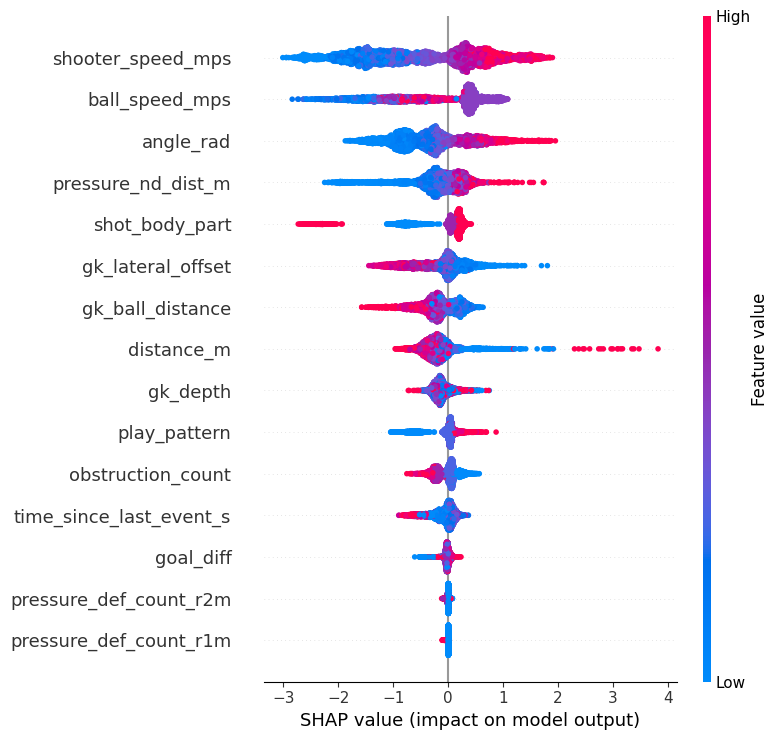

In [8]:
shap.summary_plot(shap_values, X_all, feature_names=feature_names, show=False)
plt.savefig("/Users/mariusschonberg/Desktop/Speciale/thesis/figures/shap_xgb_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
vals = np.abs(shap_values).mean(axis=0)
top = pd.Series(vals, index=feature_names).sort_values(ascending=False)
print("=== SHAP Feature Importance: XGBoost ===")
print(top.to_string())

=== SHAP Feature Importance: XGBoost ===
shooter_speed_mps          0.985107
ball_speed_mps             0.758897
angle_rad                  0.600040
pressure_nd_dist_m         0.358070
shot_body_part             0.342258
gk_lateral_offset          0.339552
gk_ball_distance           0.300392
distance_m                 0.282559
gk_depth                   0.165531
play_pattern               0.165324
obstruction_count          0.159693
time_since_last_event_s    0.149294
goal_diff                  0.042669
pressure_def_count_r2m     0.013141
pressure_def_count_r1m     0.009410
